In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
from tqdm import tqdm

In [2]:
preprocessed_data_folder = Path('/cellfile/projects/pol_ii_speed/jkoubele/analysis/senescent_cells/results/preprocessing')

protein_coding_genes_df = pd.read_csv(preprocessed_data_folder / 'genomic_features' / 'protein_coding_genes.csv')
protein_coding_genes = set(protein_coding_genes_df['gene_id'])

coverages_by_sample: dict[str, pd.DataFrame] = {}
for file in tqdm((preprocessed_data_folder / 'rescaled_coverage').iterdir(), desc='Loading data'):
    df = pd.read_parquet(file).set_index('intron_name')
    df = df[[x.split('_')[0] in protein_coding_genes for x in df.index]]
    coverages_by_sample[file.stem] = df    

coverages_by_conditions = {condition: sum([coverages_by_sample[sample] for sample in coverages_by_sample if sample.startswith(condition)]) for condition in ('p', 's', 'icm')}

metacoverages_by_condition = {condition: df.sum(axis=0).values for condition, df in coverages_by_conditions.items()}

bin_locations = np.linspace(0.005, 0.995, 100)

def fit_pi(coverage: np.ndarray) -> float:
    pi_values = np.linspace(0.0, 1.0, 101)[:, np.newaxis]  # shape (101, 1)    
    
    trapezoid_density = 1 + pi_values - 2 * bin_locations[np.newaxis, :] * pi_values
    
    probability = trapezoid_density / trapezoid_density.sum(axis=1, keepdims=True)
    loss = np.dot(-np.log(probability), coverage)
    
    best_pi = pi_values[loss.argmin()][0]
    return best_pi

condition_names = {'s': 'Replicative senescence', 'p': 'Proliferative', 'icm': 'ICM'}

introns_df = pd.read_csv(preprocessed_data_folder / 'genomic_features' / 'introns.bed',
                             sep='\t',
                             names=['chromosome', 'start', 'end', 'name', 'score', 'strand'],
                             dtype={"chromosome": "string", "strand": "string"})
introns_df['gene_id'] =  introns_df['name'].apply(lambda x: x.split('_')[0])
introns_df = introns_df[[x in protein_coding_genes for x in introns_df['gene_id']]]
introns_df['length'] = introns_df['end'] - introns_df['start']

length_threshold_1 = np.quantile(introns_df['length'], 0.3)
length_threshold_2 = np.quantile(introns_df['length'], 0.7)


intron_sets = {'All introns': set(introns_df['name']),
               f'Short introns (length<{int(length_threshold_1)} bp)': set(introns_df['name'][introns_df['length'] < length_threshold_1]),
               f'Middle introns ({int(length_threshold_1)}<=length<{int(length_threshold_2)} bp)': set(introns_df['name'][(length_threshold_1 <= introns_df['length']) *  (length_threshold_2 > introns_df['length'])]),
               f'Long introns (length>{int(length_threshold_2)} bp)': set(introns_df['name'][introns_df['length'] >= length_threshold_2])}

Loading data: 9it [00:04,  2.00it/s]


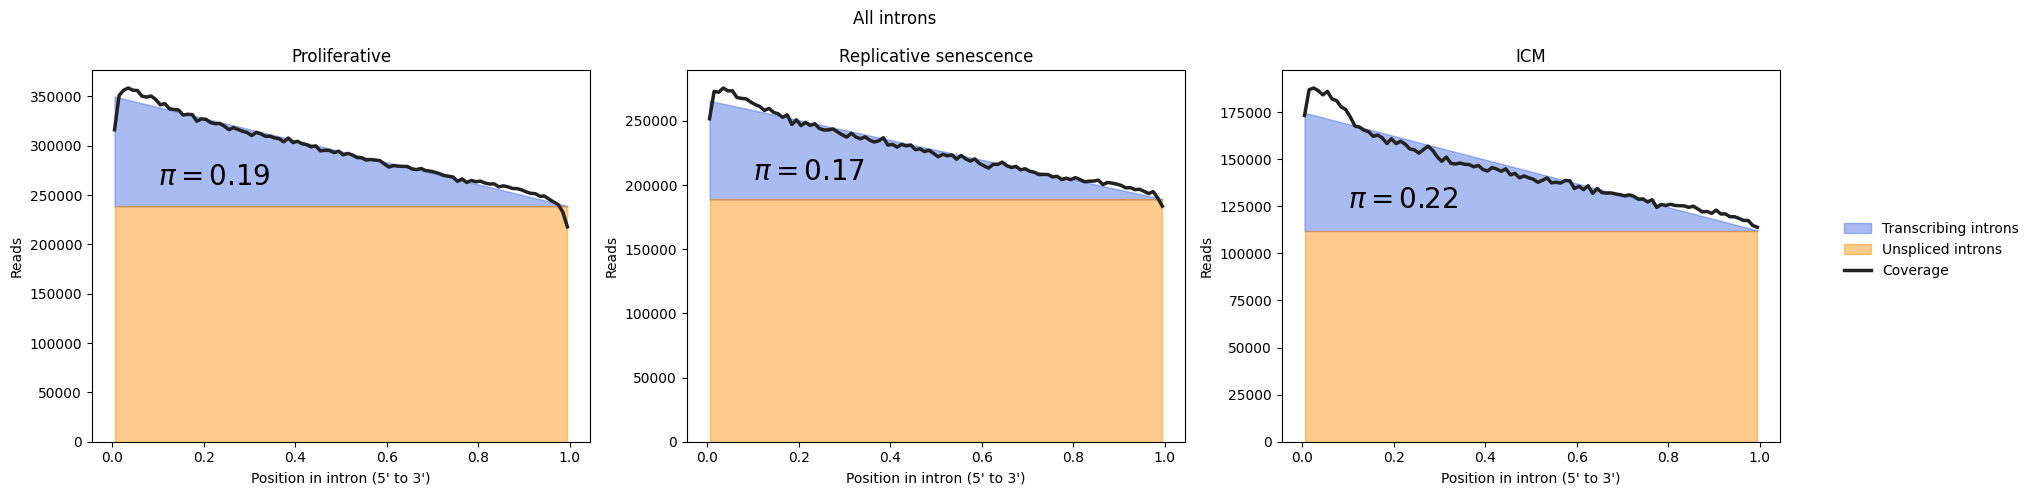

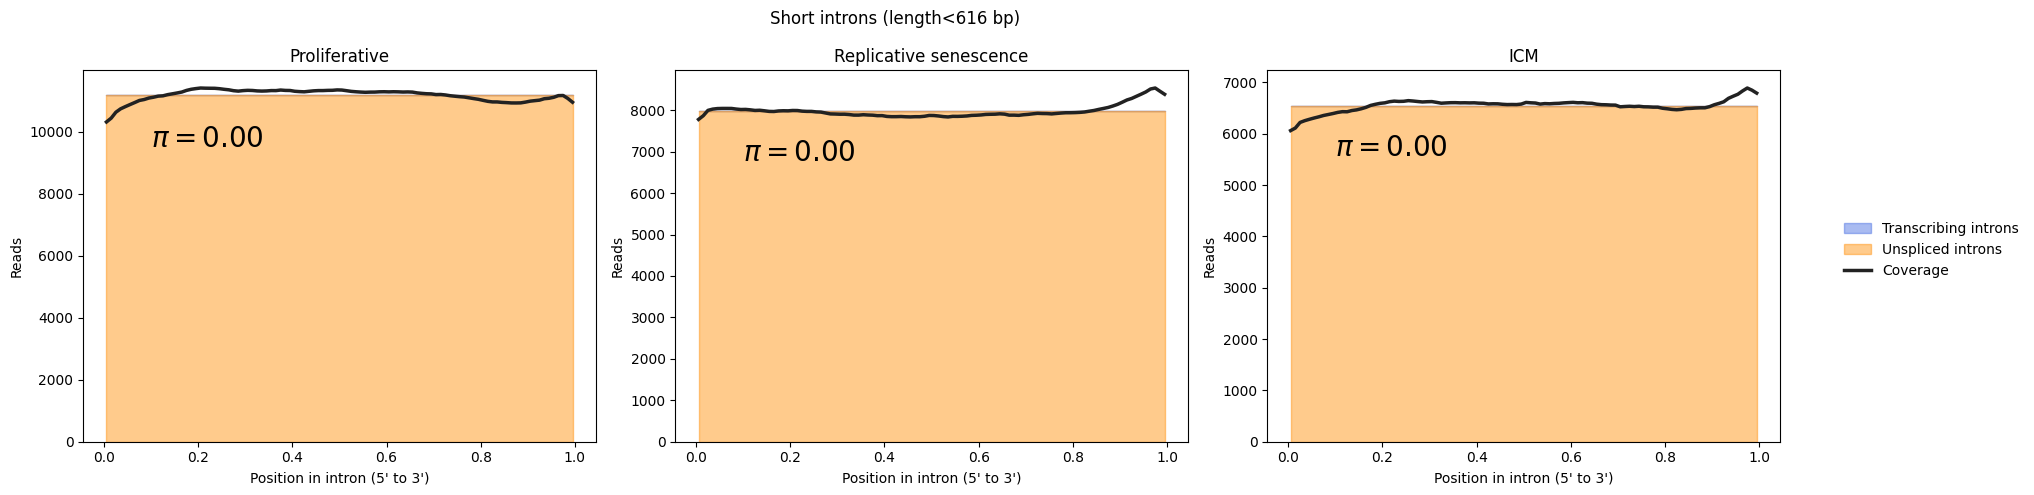

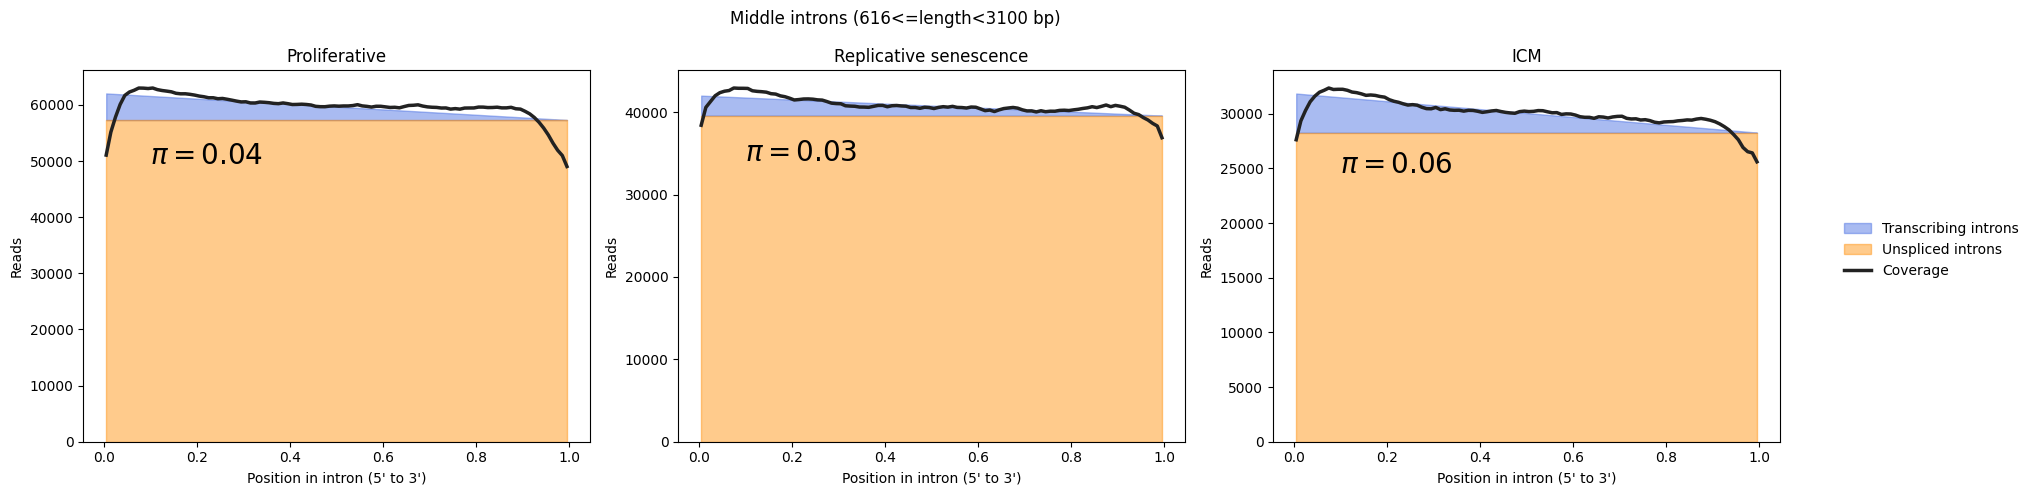

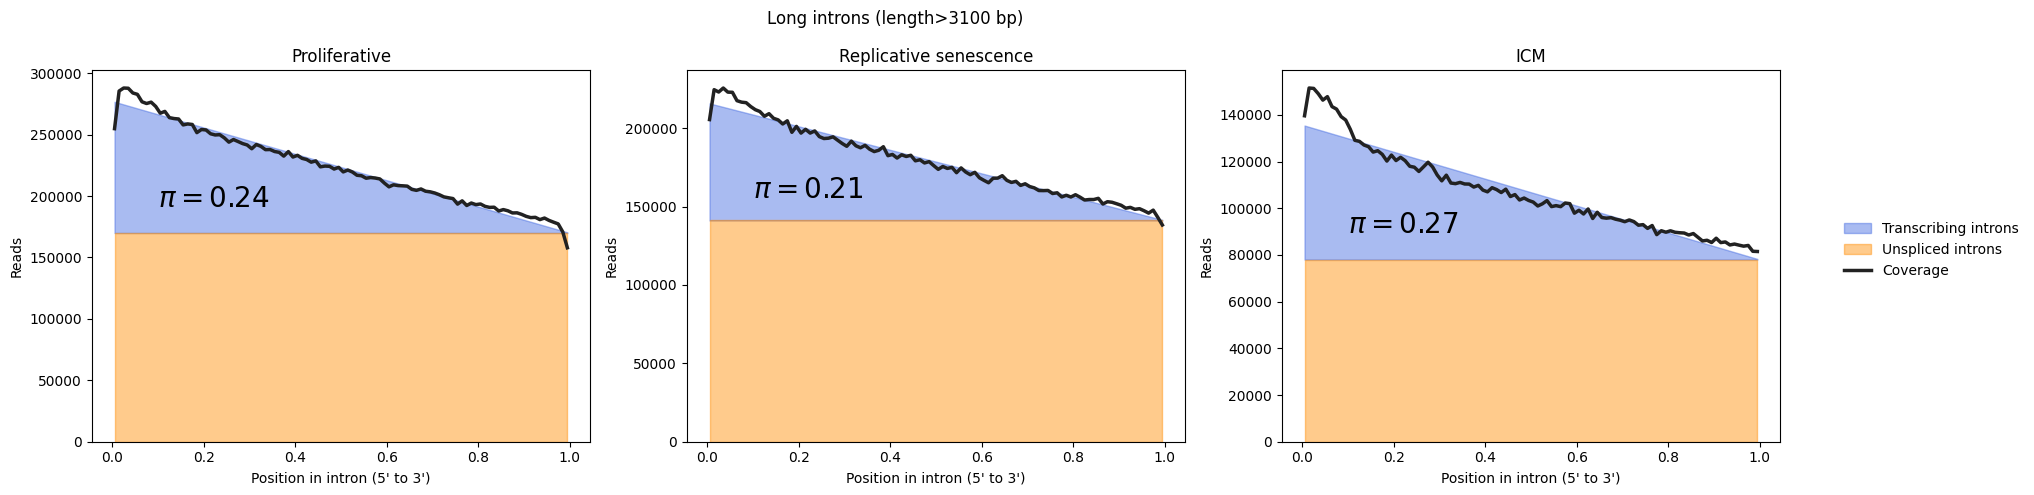

In [5]:
output_folder = Path('/cellfile/projects/rna-kinetics/intron_metacoverage/plots/')
for intron_set_name, intron_set in intron_sets.items():
    metacoverages_by_condition_and_intron_set = {
        condition: df[[x in intron_set for x in df.index]].sum(axis=0).values
        for condition, df in coverages_by_conditions.items()
    }

    conditions = list(metacoverages_by_condition_and_intron_set.keys())
    fig, axes = plt.subplots(1, len(conditions), figsize=(6 * len(conditions), 5))  # <- no sharey

    if len(conditions) == 1:
        axes = [axes]

    legend_handles = None  # <- we will capture these once

    for ax, condition in zip(axes, conditions):
        coverage = metacoverages_by_condition_and_intron_set[condition]
        pi = fit_pi(coverage)

        trapezoid_top = (1 + pi - 2 * bin_locations * pi) * coverage.sum() / len(bin_locations)
        uniform_top = np.ones_like(bin_locations) * coverage.sum() / len(bin_locations) * (1 - pi)

        h1 = ax.fill_between(
            bin_locations, trapezoid_top, y2=uniform_top,
            alpha=0.45, color='royalblue', label='Transcribing introns'
        )

        h2 = ax.fill_between(
            bin_locations, uniform_top,
            alpha=0.45, color='darkorange', label='Unspliced introns'
        )

        h3, = ax.plot(
            bin_locations, coverage,
            color='#222222', linewidth=2.5, label='Coverage'
        )

        # store handles only once
        if legend_handles is None:
            legend_handles = [h1, h2, h3]

        ax.set_xlabel("Position in intron (5' to 3')")
        ax.set_ylabel("Reads")  # <- now each subplot has its own y-axis
        ax.set_ylim(bottom=0)
        ax.set_title(condition_names[condition])

        ax.text(
            0.1,
            trapezoid_top[80] * (0.85 if pi < 0.1 else 1),
            f"$\\pi = {pi:.2f}$",
            fontsize=20,
            color='black'
        )

   
    fig.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    fig.suptitle(intron_set_name)
    fig.tight_layout()
    filename = "_".join(intron_set_name.lower().split()[:2])
    plt.savefig(output_folder / f'{filename}.png', bbox_inches='tight')
    plt.show()
    